# Lab 1 — Course Tools, Notebooks and Datasets
**Course:** Machine Learning (BSc in AI) · Week 1 · LC 1  
**Student:** <Nazerke Omarkhaliyeva>, group <IS>  
**Date:** <03.10.2026>

> Starter notebook for the Lab 1 handout. Rename it to `Lab01_<Surname>_<Name>.ipynb`, complete every **TODO**, write answers in Markdown cells, and finish with **Runtime → Restart and run all**.

## Part A — Setup
TODO (A1): replace the header above with your details.

In [5]:
print("Hello, Machine Learning!")

Hello, Machine Learning!


## Part B — Working with notebooks
### B1: execution order

In [6]:
# Cell 1 — run this FIRST
x = 10

In [7]:
# Cell 2 — run this SECOND
print(x * 2)

20


**B2 — TODO:** explain in 2–3 sentences why execution order can cause hidden bugs.

Notebook cells can be run in a different order, so a variable may keep an old value from an earlier run. This can create hidden bugs because the notebook may work now, but fail after restarting and running all cells from top to bottom.

## Part C — Library check and Python warm-up
### C1: versions

In [8]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn

print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("pandas      :", pd.__version__)
print("matplotlib  :", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

Python      : 3.13.15
NumPy       : 2.1.3
pandas      : 2.2.3
matplotlib  : 3.10.0
scikit-learn: 1.6.1


### C2: mean with a for-loop

In [9]:
scores = [72, 85, 90, 64, 78]

def mean(values):
    total = 0
    for value in values:
        total = total + value
    return total / len(values)

print(mean(scores))      # expected: 77.8
print(np.mean(scores))

77.8
77.8


### C3–C5

In [10]:
# C3: list comprehension — scores >= 70
passed = [score for score in scores if score >= 70]
print("Passed scores:", passed)

# C4: dictionary + f-string
student = {
    "name": "Nazerke Omarkhalieva",
    "group": "IS-01",
    "scores": scores
}
print(f"Student: {student['name']}, Group: {student['group']}, Scores: {student['scores']}")

# C5: NumPy array operations
a = np.array(scores)
print("Max:", a.max())
print("Min:", a.min())
print("Std:", a.std())
print("Scores increased by 10%:", a * 1.1)

Passed scores: [72, 85, 90, 78]
Student: Nazerke Omarkhalieva, Group: IS-01, Scores: [72, 85, 90, 64, 78]
Max: 90
Min: 64
Std: 9.21737489744233
Scores increased by 10%: [79.2 93.5 99.  70.4 85.8]


## Part D — Loading and exploring datasets
### D1: Iris

In [11]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [12]:
print(df.shape)
df.info()
df.describe().round(2)

(150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


In [13]:
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


**D1 — TODO:** number of samples/columns; features vs label; regression or classification; missing values; largest std; balanced?

*   Number of samples: 150
*   Number of columns in df: 6 — 4 feature columns, target, and the added species column
*   Features: sepal length, sepal width, petal length, petal width
*   Label: species
*   Task type: classification, because the goal is to predict one of three flower species
*   Missing values: none
*   Feature with the largest standard deviation: petal length (cm), approximately 1.77
*   The dataset is balanced: each species has 50 samples









### D2: first plot

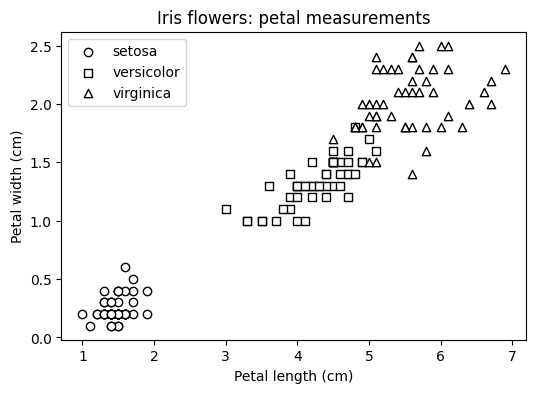

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, marker in zip(iris.target_names, ["o", "s", "^"]):
    part = df[df["species"] == name]
    ax.scatter(part["petal length (cm)"], part["petal width (cm)"],
               marker=marker, facecolor="white", edgecolor="black", label=name)
ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Petal width (cm)")
ax.set_title("Iris flowers: petal measurements")
ax.legend()
plt.show()

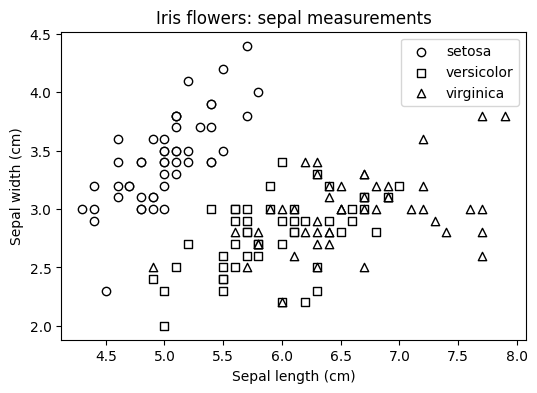

In [15]:
# TODO (D2): the same plot for sepal length vs sepal width
# D2: the same plot for sepal length vs sepal width
fig, ax = plt.subplots(figsize=(6, 4))
for name, marker in zip(iris.target_names, ["o", "s", "^"]):
    part = df[df["species"] == name]
    ax.scatter(part["sepal length (cm)"], part["sepal width (cm)"],
               marker=marker, facecolor="white", edgecolor="black", label=name)

ax.set_xlabel("Sepal length (cm)")
ax.set_ylabel("Sepal width (cm)")
ax.set_title("Iris flowers: sepal measurements")
ax.legend()
plt.show()

### D3: CSV from the web

In [16]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
print(tips.shape)
print(tips.dtypes)
print(tips.isna().sum())
tips.head()

(244, 7)
total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


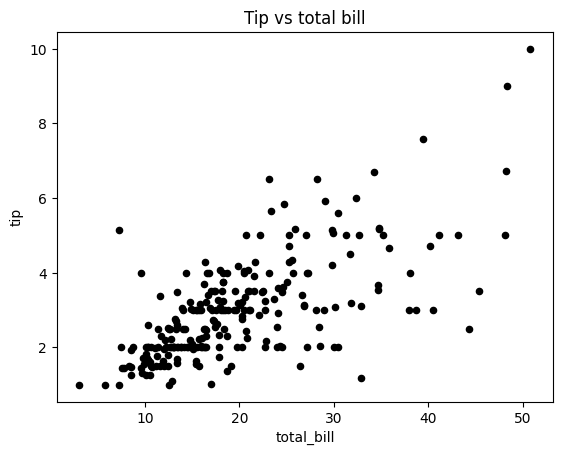

In [17]:
tips.plot.scatter(x="total_bill", y="tip", color="black", title="Tip vs total bill")
plt.show()

**D3 — TODO:** numerical vs categorical columns; predicting `tip` = ?; predicting `time` = ?; what does the plot suggest?



*   Numerical columns: total_bill, tip, size
*   Categorical columns: sex, smoker, day, time


*   Predicting tip is a regression task because tip is a numerical value
*   Predicting time is a classification task because time is a category such as Lunch or Dinner


*   The scatter plot suggests a positive relationship: larger total bills usually have larger tips, although the points are not perfectly on one line







### D4: missing values

In [18]:
titanic = pd.read_csv(
    "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv")
print(titanic.shape)
titanic.isna().sum().sort_values(ascending=False).head()

(891, 15)


,0
deck,688
age,177
embarked,2
embark_town,2
sex,0


**D4 — TODO:** which columns have missing values? Which is too incomplete to use?

The columns with missing values are deck, age, embarked, and embark_town. The deck column is the most incomplete

## Part E — Your first machine-learning model

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)                    # 1. data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)             # 2. split
model = KNeighborsClassifier(n_neighbors=5)          # 3. model
model.fit(X_train, y_train)                          # 4. train
y_pred = model.predict(X_test)                       # 5. predict
print("Accuracy:", accuracy_score(y_test, y_pred))   # 6. evaluate

Accuracy: 1.0


In [20]:
# E1: print training and test set shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)


### E2: experiment (test_size = 0.3)

In [21]:
for rs in [0, 3, 7, 42]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=rs)
    accs = []
    for k in [1, 5, 50]:
        m = KNeighborsClassifier(n_neighbors=k).fit(Xtr, ytr)
        accs.append(round(m.score(Xte, yte), 3))
    print("random_state", rs, "->", accs)

random_state 0 -> [0.978, 0.978, 0.911]
random_state 3 -> [0.956, 0.956, 0.911]
random_state 7 -> [0.933, 0.911, 0.822]
random_state 42 -> [1.0, 1.0, 0.956]


| random_state | k = 1 | k = 5 | k = 50 |
|---|---|---|---|
| 0 |  |  |  |
| 3 |  |  |  |
| 7 |  |  |  |
| 42 |  |  |  |

**E2 — TODO:** (a) why does accuracy change with `random_state`? (b) what happens with k = 50, and why?

a.   Accuracy changes with random_state because each value creates a different train/test split. Some splits are easier for the model than others, so the measured accuracy changes
b.   With k = 50, accuracy is usually lower. A very large k uses many neighbours to make each prediction, so the model becomes too smooth and may ignore important local patterns. This is a form of underfitting


### E3: predict new flowers

In [22]:
new_flowers = [[5.1, 3.5, 1.4, 0.2],
               [6.7, 3.0, 5.2, 2.3]]
pred = model.predict(new_flowers)
print(pred, iris.target_names[pred])

[0 2] ['setosa' 'virginica']


**E4 — TODO:** identify T, E and P in this program and name one limitation.



*   T (Task): classify an Iris flower into one of three species
*   E (Experience): the labelled Iris training data (X_train, y_train)


*   P (Performance measure): classification accuracy on the test set
*   One limitation: the Iris dataset is small and simple, so high accuracy here does not mean the model will perform equally well on more complex real-world data





| Field | Dataset 1 | Dataset 2 |
|---|---|---|
| Name and link | **Wine Quality** — https://archive.ics.uci.edu/dataset/186/wine+quality | **Bank Marketing** — https://archive.ics.uci.edu/dataset/222/bank+marketing |
| Source and licence | UCI Machine Learning Repository; **CC BY 4.0** | UCI Machine Learning Repository; **CC BY 4.0** |
| Rows × columns | Red wine file: **1,599 × 12** | Main `bank-full.csv` file: **45,211 × 17** |
| Target variable y | `quality` | `y` — whether the client subscribed to a term deposit |
| Task type | Regression  | Binary classification |
| 3–5 example features | `fixed acidity`, `volatile acidity`, `citric acid`, `alcohol`, `sulphates` | `age`, `job`, `balance`, `duration`, `campaign` |
| Problems noticed | Class/score imbalance; quality is subjective; some feature relationships may be nonlinear | Many categorical variables; class imbalance; `duration` can cause data leakage if prediction is supposed to happen before a call ends |
| Why is this prediction useful? | It can help estimate wine quality and support quality-control decisions | It can help a bank identify customers who may be more likely to subscribe and target marketing more efficiently |

## Reflection
1. Traditional programming vs ML?
2. Feature vs label — one example of each from `tips`.
3. Why split into training and test sets?
4. Most difficult part today, and how you will prepare for Week 2?



1.   In traditional programming, a programmer writes explicit rules that transform input into output. In machine learning, the model learns patterns from examples and then uses those patterns to make predictions on new data
2.   A feature can be total_bill. A label can be tip if the goal is to predict the tip amount.

1.  The training set is used to learn the model. The test set is kept separate so we can check how well the trained model works on unseen data
2.   The most difficult part was understanding why model accuracy changes with different train/test splits and different values of k. For Week 2, I will review NumPy, pandas, train/test splitting, and the basic idea of classification



